<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/15825_arak_Kalyani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Kalyani 3 followups AR.xlsx')

In [3]:
df.shape, df.columns

((131, 16),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'V/A PRE OP', 'numerator',
        'denominator', 'preop logMAR', 'POD 1 DAY V/A', 'numerator.1',
        'denominator.1', 'day1 logMAR', 'SPH', 'CYL', 'AXIS'],
       dtype='object'))

In [6]:
sheets = pd.ExcelFile('/content/drive/MyDrive/Kalyani 3 followups AR.xlsx')
sheets.sheet_names

['day1AR', '6weeksAR', '3monthsAR']

In [9]:
day1 = sheets.parse('day1AR')
wk6AR = sheets.parse('6weeksAR')
mth3AR = sheets.parse('3monthsAR')

In [10]:
day1.shape, day1.columns

((131, 16),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'V/A PRE OP', 'numerator',
        'denominator', 'preop logMAR', 'POD 1 DAY V/A', 'numerator.1',
        'denominator.1', 'day1 logMAR', 'SPH', 'CYL', 'AXIS'],
       dtype='object'))

In [14]:
dayF1 = day1[['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'preop logMAR', 'day1 logMAR', 'SPH', 'CYL', 'AXIS']]
dayF1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80
2,71,1,45.25,45.75,120,1.778151,0.477121,-0.75,-1.00,160
3,89,0,45.50,47.00,80,0.778151,0.301030,0.25,2.00,75
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90
...,...,...,...,...,...,...,...,...,...,...
126,66,1,43.25,44.00,60,1.000000,0.602060,-2.75,-3.00,60
127,57,1,47.00,48.25,165,0.602060,0.176091,1.25,-1.75,15
128,52,1,42.00,42.50,110,1.778151,0.301030,-0.75,-1.25,95
129,54,0,45.00,46.25,165,0.778151,0.477121,-2.75,-3.00,75


In [21]:
dayF1['preop_cyl'] = dayF1['KV'] - dayF1['KH']
dayF1['preop_axis'] = dayF1['AX']
dayF1['postop_cyl'] = dayF1['CYL']

/tmp/ipython-input-1459914626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dayF1['preop_cyl'] = dayF1['KV'] - dayF1['KH']
/tmp/ipython-input-1459914626.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dayF1['preop_axis'] = dayF1['AX']
/tmp/ipython-input-1459914626.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [22]:
dayF1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS,preopcyl,postopcyl,preop_cyl,preop_axis,postop_cyl
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115,0.75,-1.50,0.75,155,-1.50
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80,1.25,-2.25,1.25,80,-2.25
2,71,1,45.25,45.75,120,1.778151,0.477121,-0.75,-1.00,160,0.50,-1.00,0.50,120,-1.00
3,89,0,45.50,47.00,80,0.778151,0.301030,0.25,2.00,75,1.50,2.00,1.50,80,2.00
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90,1.00,-2.00,1.00,75,-2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,66,1,43.25,44.00,60,1.000000,0.602060,-2.75,-3.00,60,0.75,-3.00,0.75,60,-3.00
127,57,1,47.00,48.25,165,0.602060,0.176091,1.25,-1.75,15,1.25,-1.75,1.25,165,-1.75
128,52,1,42.00,42.50,110,1.778151,0.301030,-0.75,-1.25,95,0.50,-1.25,0.50,110,-1.25
129,54,0,45.00,46.25,165,0.778151,0.477121,-2.75,-3.00,75,1.25,-3.00,1.25,165,-3.00


In [44]:
# Create a new column 'Classification' in day1ARclean
dayF1['Classification'] = dayF1.apply(
    lambda row: 'Compound myopic astigmatism' if row['SPH'] < 0 and row['CYL'] < 0 else
                'Compound hyperopic astigmatism' if row['SPH'] > 0 and row['CYL'] > 0 else
    'Simple myopic astigmatism' if row['SPH'] == 0 and row['CYL'] < 0 else
    'Simple hyperopic astigmatism' if row['SPH'] == 0 and row['CYL'] > 0 else
                'Mixed astigmatism',
    axis=1
)

# View result
print(dayF1[['SPH', 'CYL', 'AXIS','Classification']])

      SPH   CYL  AXIS                  Classification
0    0.25 -1.50   115               Mixed astigmatism
1    0.75 -2.25    80               Mixed astigmatism
2   -0.75 -1.00   160     Compound myopic astigmatism
3    0.25  2.00    75  Compound hyperopic astigmatism
4    2.00 -2.00    90               Mixed astigmatism
..    ...   ...   ...                             ...
126 -2.75 -3.00    60     Compound myopic astigmatism
127  1.25 -1.75    15               Mixed astigmatism
128 -0.75 -1.25    95     Compound myopic astigmatism
129 -2.75 -3.00    75     Compound myopic astigmatism
130 -3.25 -3.00    40     Compound myopic astigmatism

[131 rows x 4 columns]


In [45]:
# Frequency of each refractive error type
classification_counts = dayF1['Classification'].value_counts()
print(classification_counts)

Classification
Mixed astigmatism                 62
Compound myopic astigmatism       48
Compound hyperopic astigmatism    14
Simple myopic astigmatism          6
Simple hyperopic astigmatism       1
Name: count, dtype: int64


In [54]:
# Separate Astigmatisms
mixed_df1 = dayF1[dayF1['Classification'] == 'Mixed astigmatism']
C_myopic_df1 = dayF1[dayF1['Classification']=='Compound myopic astigmatism']
C_hyperopic_df1 = dayF1[dayF1['Classification']=='Compound hyperopic astigmatism']
S_myopic_df1 = dayF1[dayF1['Classification'] == 'Simple myopic astigmatism']
S_hyperopic_df1 = dayF1[dayF1['Classification'] == 'Simple hyperopic astigmatism']


In [58]:
mixed_df1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS,preopcyl,postopcyl,preop_cyl,preop_axis,postop_cyl,Classification
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115,0.75,-1.50,0.75,155,-1.50,Mixed astigmatism
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80,1.25,-2.25,1.25,80,-2.25,Mixed astigmatism
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90,1.00,-2.00,1.00,75,-2.00,Mixed astigmatism
5,71,1,43.50,44.00,20,1.778151,0.477121,-0.50,3.75,75,0.50,3.75,0.50,20,3.75,Mixed astigmatism
7,62,1,44.75,45.25,85,0.778151,0.301030,1.50,-3.25,45,0.50,-3.25,0.50,85,-3.25,Mixed astigmatism
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,74,1,45.25,45.50,30,1.477121,0.301030,2.50,-1.00,65,0.25,-1.00,0.25,30,-1.00,Mixed astigmatism
118,65,1,44.25,45.75,80,0.301030,0.301030,1.25,-1.00,80,1.50,-1.00,1.50,80,-1.00,Mixed astigmatism
122,59,1,41.75,43.50,160,2.301030,0.301030,-2.25,3.00,50,1.75,3.00,1.75,160,3.00,Mixed astigmatism
124,72,1,45.25,45.25,180,0.477121,0.301030,1.75,-4.25,95,0.00,-4.25,0.00,180,-4.25,Mixed astigmatism


In [61]:

# Step 1: Pre- and Post-op Cylinder
# mixed_df['preopcyl'] = mixed_df['KV'] - mixed_df['KH']
# mixed_df['postopcyl'] = mixed_df['CYL']  # or use another post-op column if different

# Step 2: Convert axis to double angle in radians
mixed_df1['pre_theta'] = np.deg2rad(mixed_df1['AX'] * 2)
mixed_df1['post_theta'] = np.deg2rad(mixed_df1['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates
mixed_df1['pre_x'] = mixed_df1['preop_cyl'] * np.cos(mixed_df1['pre_theta'])
mixed_df1['pre_y'] = mixed_df1['preop_cyl'] * np.sin(mixed_df1['pre_theta'])

mixed_df1['post_x'] = mixed_df1['postop_cyl'] * np.cos(mixed_df1['post_theta'])
mixed_df1['post_y'] = mixed_df1['postop_cyl'] * np.sin(mixed_df1['post_theta'])

# Step 4: Compute SIA vector components
mixed_df1['sia_x'] = mixed_df1['post_x'] - mixed_df1['pre_x']
mixed_df1['sia_y'] = mixed_df1['post_y'] - mixed_df1['pre_y']

# Step 5: Compute SIA magnitude and axis
mixed_df1['SIA_magnitude'] = np.sqrt(mixed_df1['sia_x']**2 + mixed_df1['sia_y']**2)
mixed_df1['SIA_axis'] = (np.rad2deg(np.arctan2(mixed_df1['sia_y'], mixed_df1['sia_x'])) / 2) % 180

# Step 6: Round for neat display
mixed_df1['SIA_magnitude'] = mixed_df1['SIA_magnitude'].round(2)
mixed_df1['SIA_axis'] = mixed_df1['SIA_axis'].round(1)

# Show the final results
print(mixed_df1[['SIA_magnitude', 'SIA_axis']])

     SIA_magnitude  SIA_axis
0             1.79      37.2
1             3.50     170.0
4             2.91     175.1
5             3.95      78.4
7             3.37     139.2
..             ...       ...
113           1.11     148.9
118           2.50     170.0
122           4.48      57.3
124           4.25       5.0
127           2.61      92.7

[62 rows x 2 columns]


/tmp/ipython-input-1803983002.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df1['pre_theta'] = np.deg2rad(mixed_df1['AX'] * 2)
/tmp/ipython-input-1803983002.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df1['post_theta'] = np.deg2rad(mixed_df1['AXIS'] * 2)
/tmp/ipython-input-1803983002.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [62]:
mixed_df1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS,...,pre_theta,post_theta,pre_x,pre_y,post_x,post_y,sia_x,sia_y,SIA_magnitude,SIA_axis
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115,...,5.410521,4.014257,0.482091,-0.574533,9.641814e-01,1.149067e+00,0.482091,1.723600,1.79,37.2
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80,...,2.792527,2.792527,-1.174616,0.427525,2.114308e+00,-7.695453e-01,3.288924,-1.197071,3.50,170.0
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90,...,2.617994,3.141593,-0.866025,0.500000,2.000000e+00,-2.449294e-16,2.866025,-0.500000,2.91,175.1
5,71,1,43.50,44.00,20,1.778151,0.477121,-0.50,3.75,75,...,0.698132,2.617994,0.383022,0.321394,-3.247595e+00,1.875000e+00,-3.630617,1.553606,3.95,78.4
7,62,1,44.75,45.25,85,0.778151,0.301030,1.50,-3.25,45,...,2.967060,1.570796,-0.492404,0.086824,-1.990051e-16,-3.250000e+00,0.492404,-3.336824,3.37,139.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,74,1,45.25,45.50,30,1.477121,0.301030,2.50,-1.00,65,...,1.047198,2.268928,0.125000,0.216506,6.427876e-01,-7.660444e-01,0.517788,-0.982551,1.11,148.9
118,65,1,44.25,45.75,80,0.301030,0.301030,1.25,-1.00,80,...,2.792527,2.792527,-1.409539,0.513030,9.396926e-01,-3.420201e-01,2.349232,-0.855050,2.50,170.0
122,59,1,41.75,43.50,160,2.301030,0.301030,-2.25,3.00,50,...,5.585054,1.745329,1.340578,-1.124878,-5.209445e-01,2.954423e+00,-1.861522,4.079302,4.48,57.3
124,72,1,45.25,45.25,180,0.477121,0.301030,1.75,-4.25,95,...,6.283185,3.316126,0.000000,-0.000000,4.185433e+00,7.380048e-01,4.185433,0.738005,4.25,5.0


In [84]:
mixed_df1[['SIA_magnitude','SIA_axis']].describe()

,SIA_magnitude,SIA_axis
count,62.000000,62.000000
mean,2.764677,111.154839
std,1.425000,66.467879
min,0.250000,0.900000
25%,1.665000,54.150000
50%,2.720000,144.050000
75%,3.500000,170.000000
max,6.340000,179.300000


array([[<Axes: title={'center': 'SIA_magnitude'}>,
        <Axes: title={'center': 'SIA_axis'}>]], dtype=object)

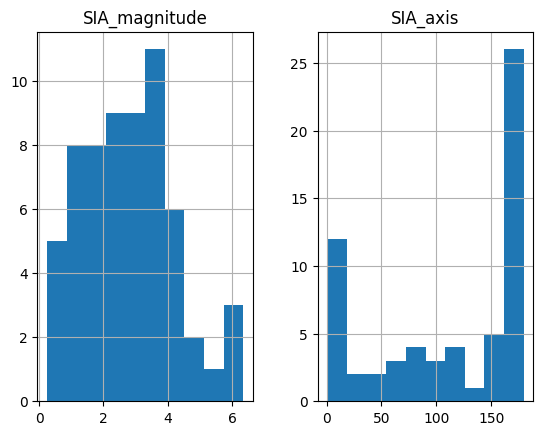

In [85]:
mixed_df1[['SIA_magnitude','SIA_axis']].hist()

<Axes: >

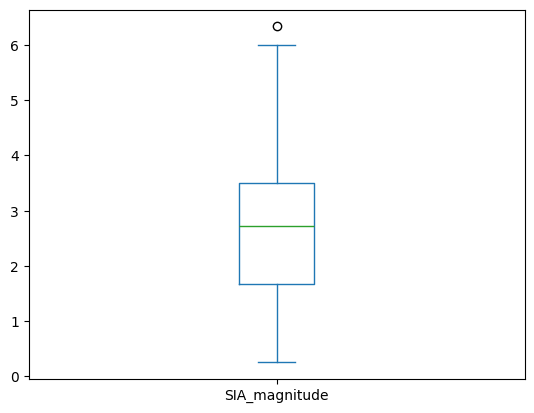

In [89]:
mixed_df1['SIA_magnitude'].plot.box()

<Axes: >

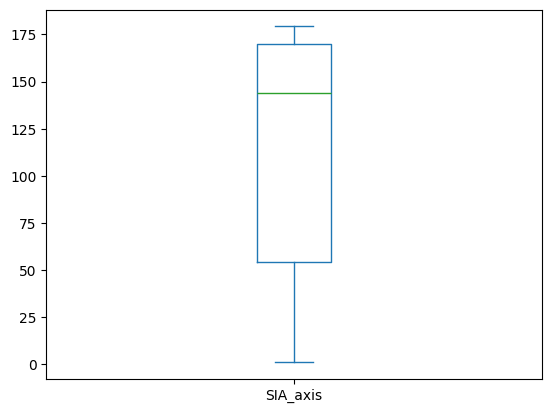

In [79]:
mixed_df1['SIA_axis'].plot.box()

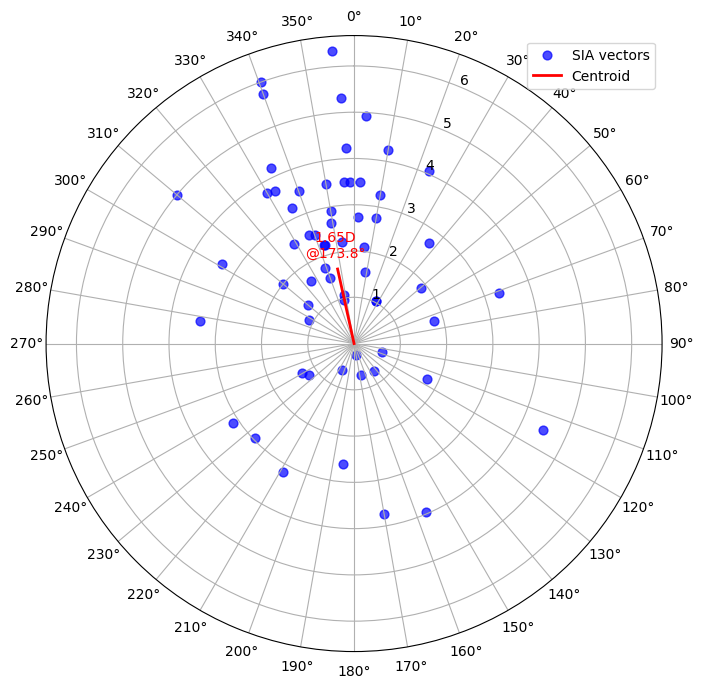

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in mixed_df1.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = mixed_df1['sia_x'].mean()
centroid_y = mixed_df1['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(mixed_df1['SIA_axis'] * 2)  # double-angle domain
r = mixed_df1['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()